## 0. Imports e Configurações

In [1]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay)


In [2]:
ionosphere = fetch_ucirepo(id=52)
X_raw = ionosphere.data.features
y_raw = ionosphere.data.targets

print("Shape dos atributos:", X_raw.shape)
print("\nDistribuição das classes:")
print(y_raw.value_counts())
X_raw.head()

Shape dos atributos: (351, 34)

Distribuição das classes:
Class
g        225
b        126
Name: count, dtype: int64


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.20332,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,0.57528,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,1.00000,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,0.03286,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697


In [3]:

y = np.where(y_raw.values.ravel() == 'g', 1, -1)
X = X_raw.values.copy()

print("Classes únicas após recodificação:", np.unique(y))
print(f"  +1 (good): {(y ==  1).sum()} amostras")
print(f"  -1 (bad) : {(y == -1).sum()} amostras")

Classes únicas após recodificação: [-1  1]
  +1 (good): 225 amostras
  -1 (bad) : 126 amostras


In [4]:
df = pd.DataFrame(X, columns=X_raw.columns)

missing = df.isnull().sum().sum()
print(f"Valores ausentes: {missing}")

zero_var = df.columns[df.std() == 0].tolist()
print(f"Atributos constantes (variância = 0): {zero_var}")

if zero_var:
    df.drop(columns=zero_var, inplace=True)
    X = df.values
    print(f"→ Removidos. Novo shape: {X.shape}")
else:
    print("→ Nenhum atributo constante. Shape mantido:", X.shape)

Valores ausentes: 0
Atributos constantes (variância = 0): ['Attribute2']
→ Removidos. Novo shape: (351, 33)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Amostras de treino : {X_train.shape[0]}")
print(f"Amostras de teste  : {X_test.shape[0]}")
print(f"Atributos          : {X_train.shape[1]}")
print(f"\nDistribuição no treino → +1: {(y_train==1).sum()}  | -1: {(y_train==-1).sum()}")
print(f"Distribuição no teste  → +1: {(y_test ==1).sum()}  | -1: {(y_test ==-1).sum()}")

Amostras de treino : 280
Amostras de teste  : 71
Atributos          : 33

Distribuição no treino → +1: 179  | -1: 101
Distribuição no teste  → +1: 46  | -1: 25


In [6]:
class AdalineManual:
    """Adaline com gradiente descendente estocástico (online)."""

    def __init__(self, learning_rate=0.001, n_epochs=200):
        self.lr       = learning_rate
        self.n_epochs = n_epochs
        self.weights  = None
        self.cost_    = []

    def fit(self, X_raw, yd):

        X        = np.column_stack((-1.0 * np.ones(X_raw.shape[0]), X_raw))
        w        = 0.1 * np.random.randn(X.shape[1])
        n        = X.shape[0]
        indexes  = np.arange(n)

        for _ in range(self.n_epochs):
            np.random.shuffle(indexes)
            epoch_cost = 0.0
            for idx in indexes:
                u           = np.dot(X[idx], w)
                error       = yd[idx] - u
                w          += self.lr * X[idx] * error
                epoch_cost += error ** 2
            self.cost_.append(epoch_cost / n)

        self.weights = w
        return self

    def predict(self, X_raw):
        X = np.column_stack((-1.0 * np.ones(X_raw.shape[0]), X_raw))
        u = np.dot(X, self.weights)
        return np.where(u >= 0.0, 1, -1)

/tmp/ipykernel_9763/823775581.py:24: RuntimeWarning: overflow encountered in scalar add
  epoch_cost += error ** 2
/tmp/ipykernel_9763/823775581.py:24: RuntimeWarning: overflow encountered in scalar power
  epoch_cost += error ** 2


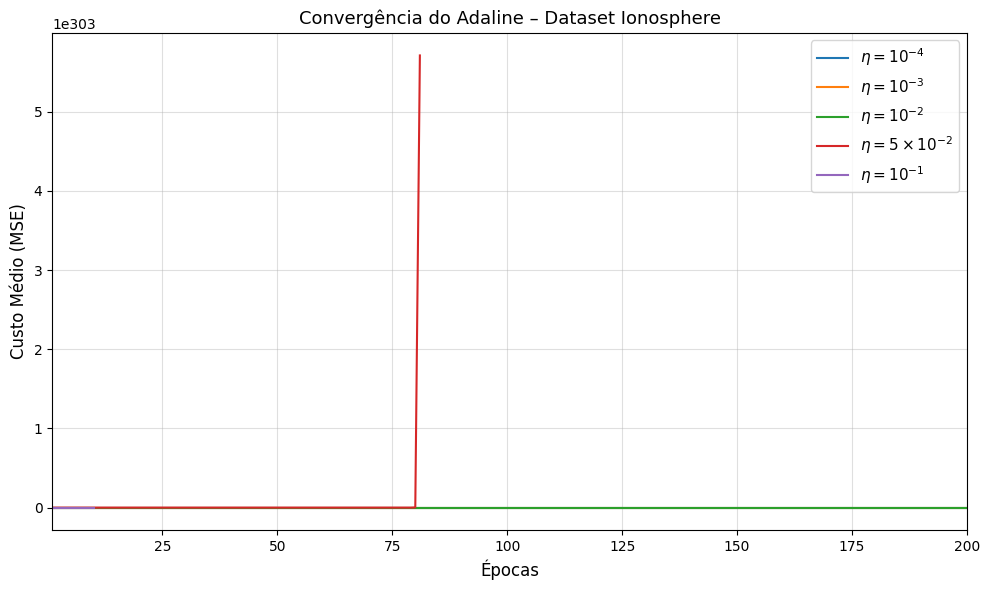


Custo final (última época):
  $\eta = 10^{-4}$                   : 0.385760
  $\eta = 10^{-3}$                   : 0.383613
  $\eta = 10^{-2}$                   : 0.506333
  $\eta = 5\times10^{-2}$            : nan
  $\eta = 10^{-1}$                   : nan


In [7]:
N_EPOCHS   = 200
SEED       = 42
taxas      = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
labels_eta = [r'$\eta = 10^{-4}$', r'$\eta = 10^{-3}$',
              r'$\eta = 10^{-2}$', r'$\eta = 5\times10^{-2}$',
              r'$\eta = 10^{-1}$']

modelos = {}

np.random.seed(SEED)
for eta, label in zip(taxas, labels_eta):
    model = AdalineManual(learning_rate=eta, n_epochs=N_EPOCHS)
    model.fit(X_train, y_train)
    modelos[label] = model

fig, ax = plt.subplots(figsize=(10, 6))
epochs  = np.arange(1, N_EPOCHS + 1)

for label, model in modelos.items():
    ax.plot(epochs, model.cost_, label=label)

ax.set_xlabel('Épocas', fontsize=12)
ax.set_ylabel('Custo Médio (MSE)', fontsize=12)
ax.set_title('Convergência do Adaline – Dataset Ionosphere', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([1, N_EPOCHS])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nCusto final (última época):")
for label, model in modelos.items():
    print(f"  {label:35s}: {model.cost_[-1]:.6f}")

Melhor η encontrado: $\eta = 10^{-3}$  (η = 0.001)
Custo final: 0.383613


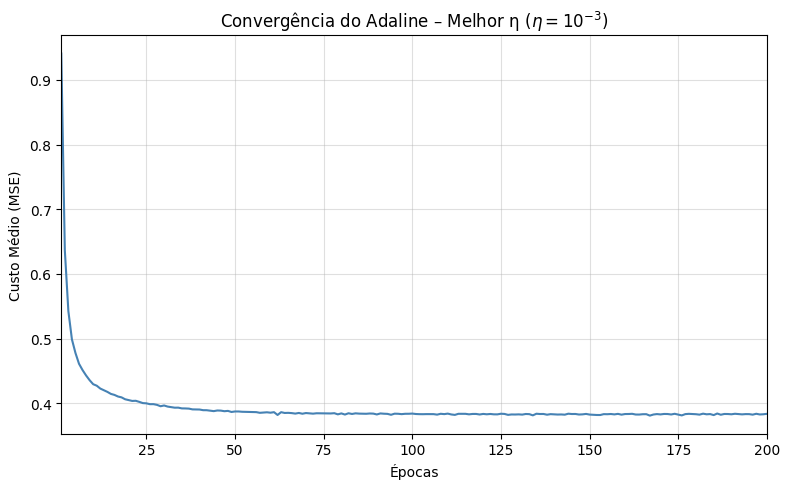

In [8]:
custos_finais = {label: model.cost_[-1] for label, model in modelos.items()}
melhor_label  = min(custos_finais, key=custos_finais.get)
melhor_eta    = taxas[labels_eta.index(melhor_label)]

print(f"Melhor η encontrado: {melhor_label}  (η = {melhor_eta})")
print(f"Custo final: {custos_finais[melhor_label]:.6f}")

melhor_modelo = modelos[melhor_label]

plt.figure(figsize=(8, 5))
plt.plot(epochs, melhor_modelo.cost_, color='steelblue')
plt.xlabel('Épocas')
plt.ylabel('Custo Médio (MSE)')
plt.title(f'Convergência do Adaline – Melhor η ({melhor_label})')
plt.xlim([1, N_EPOCHS])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Matriz de Confusão (Manual):
[[19  6]
 [ 0 46]]


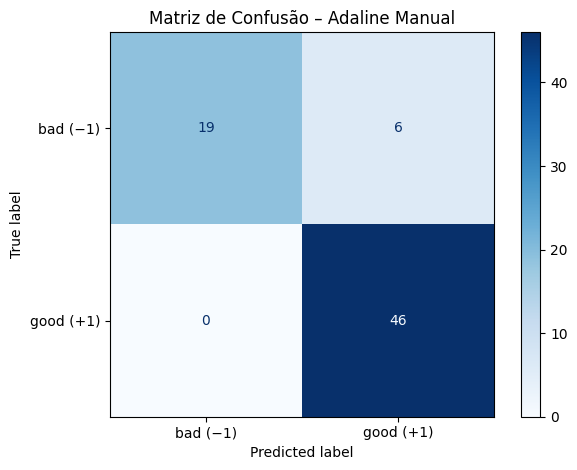

In [9]:
np.random.seed(SEED)
adaline_manual = AdalineManual(learning_rate=melhor_eta, n_epochs=N_EPOCHS)
adaline_manual.fit(X_train, y_train)

y_pred_manual = adaline_manual.predict(X_test)

cm_manual = confusion_matrix(y_test, y_pred_manual, labels=[-1, 1])
print("Matriz de Confusão (Manual):")
print(cm_manual)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_manual,
                               display_labels=['bad (−1)', 'good (+1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão – Adaline Manual')
plt.tight_layout()
plt.show()

In [10]:
print("=== Métricas – Adaline Manual ===")
print(f"Acurácia  : {accuracy_score(y_test, y_pred_manual):.4f}")
print(f"Precisão  : {precision_score(y_test, y_pred_manual, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_manual, pos_label=1):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_manual, pos_label=1):.4f}")

=== Métricas – Adaline Manual ===
Acurácia  : 0.9155
Precisão  : 0.8846
Recall    : 1.0000
F1-Score  : 0.9388


Matriz de Confusão (sklearn):
[[22  3]
 [ 0 46]]


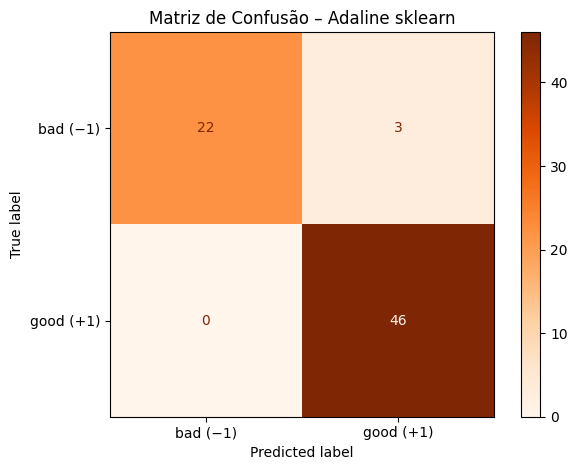

In [11]:
adaline_sklearn = SGDClassifier(
    loss='squared_error',
    eta0=melhor_eta,
    learning_rate='constant',
    max_iter=N_EPOCHS,
    shuffle=True,
    random_state=SEED
)
adaline_sklearn.fit(X_train, y_train)
y_pred_sklearn = adaline_sklearn.predict(X_test)

cm_sk = confusion_matrix(y_test, y_pred_sklearn, labels=[-1, 1])
print("Matriz de Confusão (sklearn):")
print(cm_sk)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_sk,
                                display_labels=['bad (−1)', 'good (+1)'])
disp2.plot(cmap='Oranges')
plt.title('Matriz de Confusão – Adaline sklearn')
plt.tight_layout()
plt.show()

In [12]:
print("=== Métricas – Adaline sklearn ===")
print(f"Acurácia  : {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"Precisão  : {precision_score(y_test, y_pred_sklearn, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_sklearn, pos_label=1):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_sklearn, pos_label=1):.4f}")

=== Métricas – Adaline sklearn ===
Acurácia  : 0.9577
Precisão  : 0.9388
Recall    : 1.0000
F1-Score  : 0.9684


In [13]:

cm = confusion_matrix(y_test, y_pred_manual, labels=[-1, 1])

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

recall_bad = TN / (TN + FP) if (TN + FP) > 0 else 0

print("=== Análise de Erros – Adaline Manual ===")
print(f"Verdadeiros Negativos (bad→bad)  : {TN}")
print(f"Falsos Positivos  (bad→good) [FP]: {FP}  ← alerta desnecessário")
print(f"Falsos Negativos  (good→bad) [FN]: {FN}")
print(f"Verdadeiros Positivos (good→good): {TP}")
print()
print(f"Recall da classe bad (−1): {recall_bad:.4f}")
print(f"→ {FP} retornos 'bad' foram classificados como 'good' (erro crítico).")

=== Análise de Erros – Adaline Manual ===
Verdadeiros Negativos (bad→bad)  : 19
Falsos Positivos  (bad→good) [FP]: 6  ← alerta desnecessário
Falsos Negativos  (good→bad) [FN]: 0
Verdadeiros Positivos (good→good): 46

Recall da classe bad (−1): 0.7600
→ 6 retornos 'bad' foram classificados como 'good' (erro crítico).
